AI-BASED FOOTBALL SCOUTING
 
Evaluate Player Performance & Transfer Suitability

Using XGBoost & the Justice Formula


1 - Hadi Al-Hajji(L)| 2230000809

2 - Mahdi Al-Khamis | 2230006859 

3 - Omar Al-Subgh   | 2210002182 

## Imports & Global Setup

In [1]:
import pandas as pd
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, accuracy_score, roc_auc_score, 
                             f1_score, log_loss, roc_curve, auc, confusion_matrix, precision_score, recall_score)
from xgboost.callback import EarlyStopping
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, log_loss

sns.set_theme(style="whitegrid")

## PHASE 1: DATA EXTRACTION


In [3]:
# Define local data directory and filtering parameters for specific leagues
base_path = 'open-data-master/data'
target_competitions = [11, 7, 9, 2, 12]
match_limit = 200

# Identify all seasons corresponding to the target competitions
all_seasons = []
with open(os.path.join(base_path, 'competitions.json'), 'r', encoding='utf-8') as f:
    comps_data = json.load(f)
    for comp in comps_data:
        if comp['competition_id'] in target_competitions:
            all_seasons.append({
                'comp_id': comp['competition_id'],
                'season_id': comp['season_id'],
                'season_name': comp['season_name']
            })

# Sort seasons by name in descending order to prioritize recent data
all_seasons = sorted(all_seasons, key=lambda x: x['season_name'], reverse=True)

# Collect all unique match IDs from the identified seasons
match_ids = []
for season in all_seasons:
    match_file = os.path.join(base_path, f"matches/{season['comp_id']}/{season['season_id']}.json")
    if os.path.exists(match_file):
        with open(match_file, 'r', encoding='utf-8') as f:
            matches_data = json.load(f)
            for m in matches_data:
                match_ids.append(m['match_id'])

# Extract event data only for relevant gameplay actions
extracted_data = []
relevant_actions = ['Shot', 'Pass', 'Interception', 'Duel', 'Clearance', 'Carry']

# Iterate through match IDs up to the defined limit and parse event files
for m_id in match_ids[:match_limit]:
    event_path = os.path.join(base_path, f'events/{m_id}.json')
    if os.path.exists(event_path):
        with open(event_path, 'r', encoding='utf-8') as f:
            # Flatten nested JSON structure into a DataFrame
            events_df = pd.json_normalize(json.load(f))
            # Filter rows based on pre-defined action types
            events_df = events_df[events_df['type.name'].isin(relevant_actions)].copy()
            events_df['match_id'] = m_id
            extracted_data.append(events_df)

# Consolidate all individual match event DataFrames into one master dataset
final_dataset = pd.concat(extracted_data, ignore_index=True)
print(f"Phase 1 Complete: {len(final_dataset)} events collected.")

ValueError: No objects to concatenate

## PHASE 2: PREPROCESSING


In [ ]:
# Create a copy to avoid SettingWithCopy warnings
final_dataset = final_dataset.copy()

# Extract X and Y coordinates from the nested list format into separate columns
locs = pd.DataFrame(final_dataset['location'].tolist(), columns=['location_x', 'location_y'], index=final_dataset.index)
final_dataset = pd.concat([final_dataset, locs], axis=1)

# Impute missing pressure values as 0 (not under pressure) and convert to integer
final_dataset['under_pressure'] = final_dataset['under_pressure'].fillna(0).astype(int)

# Engineer target features: identify successful goals and assists from nested event data
final_dataset['is_goal']   = (final_dataset['shot.outcome.name'] == 'Goal').astype(int)
final_dataset['is_assist'] = (final_dataset['pass.goal_assist'] == True).astype(int)

# FIX: Include 'Duel' and 'Carry' in the analysis while excluding goalkeeper events
final_dataset = final_dataset[final_dataset['position.name'] != 'Goalkeeper'].copy()

print(f"Phase 2 Complete: Dataset preprocessed with {len(final_dataset)} events.")

Phase 2 Complete: Dataset preprocessed with 422084 events.


## PHASE 3: VISUALIZATIONS


Missing columns: []


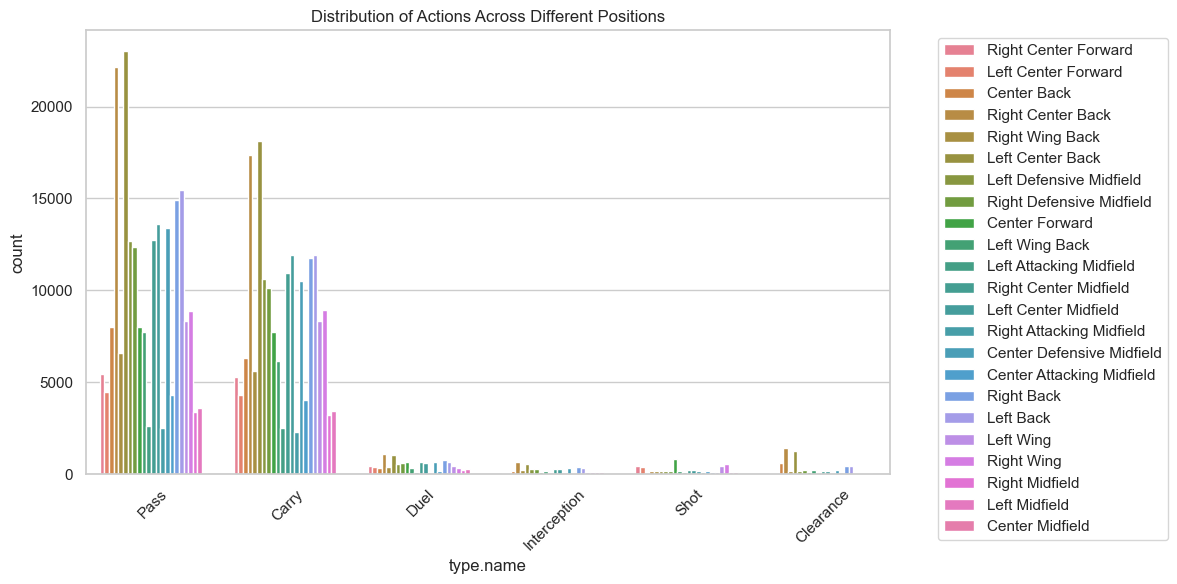

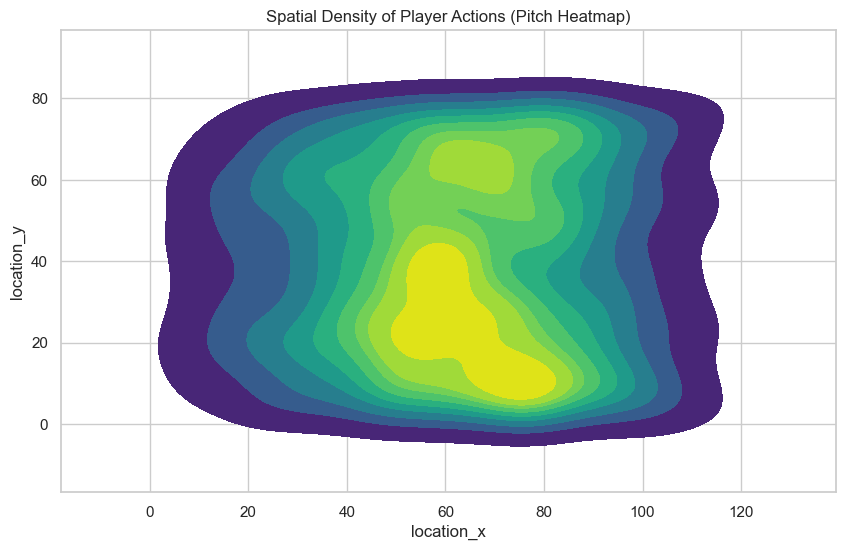

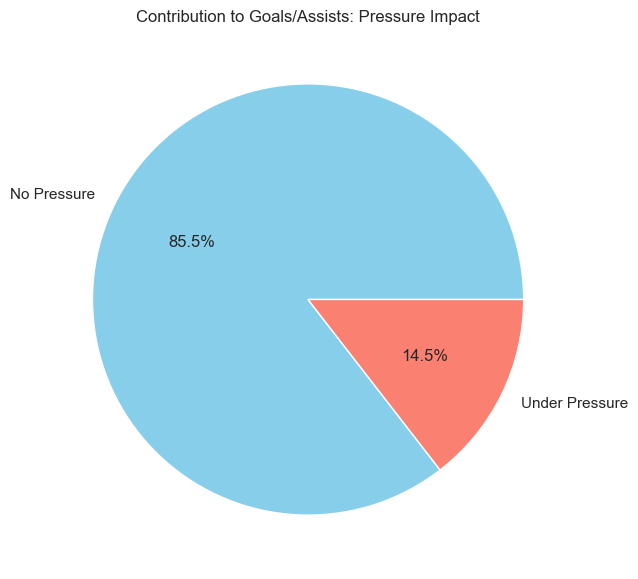

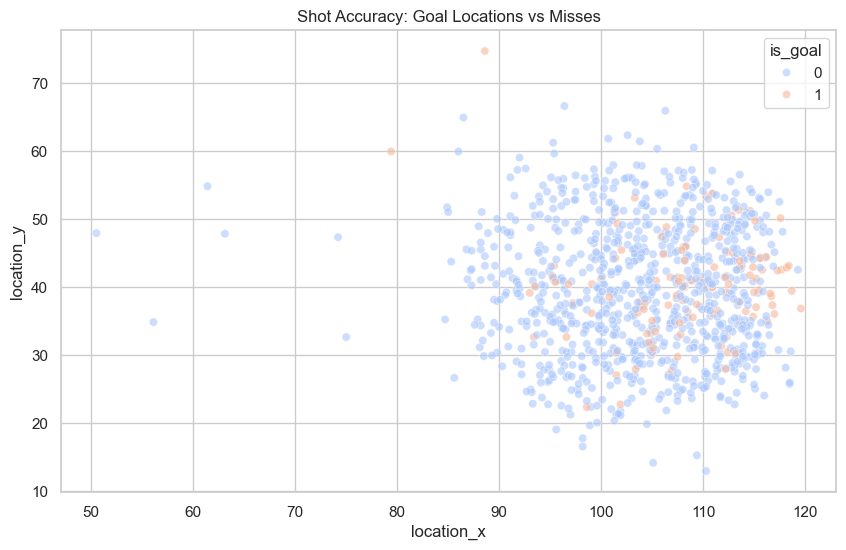

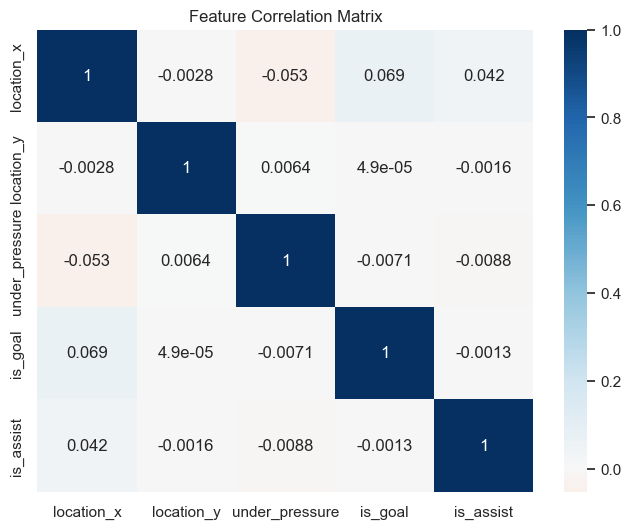

C:\Users\Iihuy\AppData\Local\Temp\ipykernel_11416\1387038131.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Figure size 1200x600 with 0 Axes>

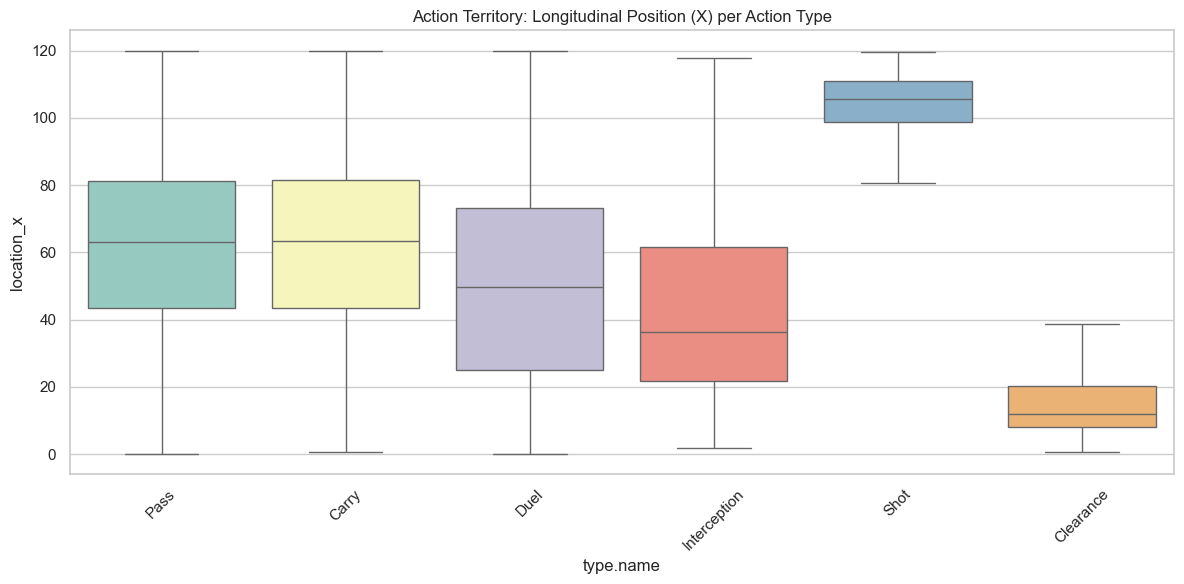

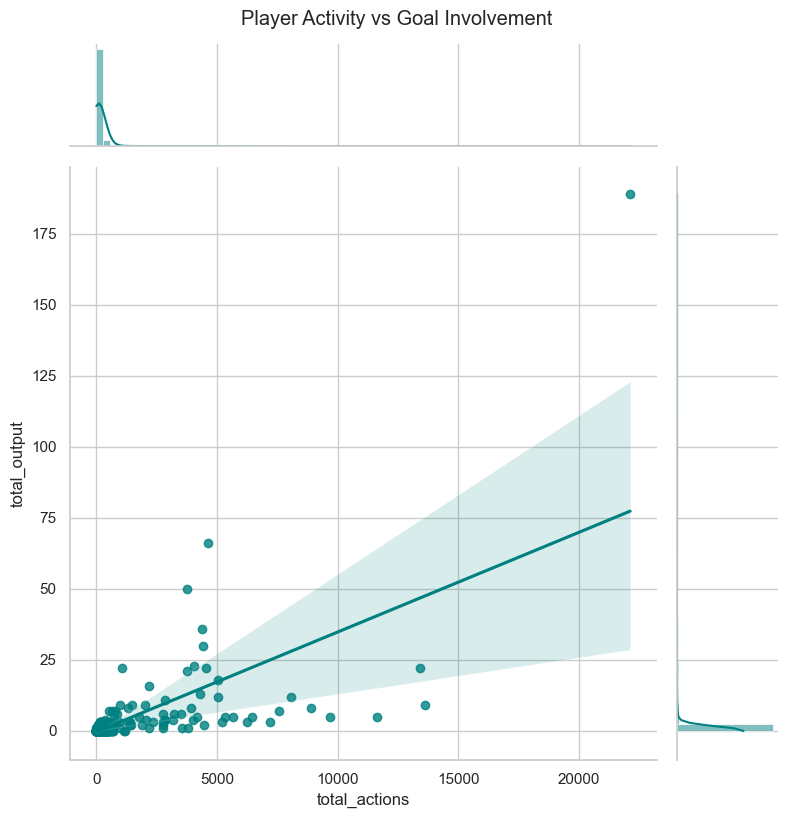

In [ ]:
# Check for any missing columns to prevent KeyError during plotting
required_cols = [
    'type.name',
    'position.name',
    'location_x',
    'location_y',
    'under_pressure',
    'is_goal',
    'is_assist',
    'player.name'
]

missing = [c for c in required_cols if c not in final_dataset.columns]
print("Missing columns:", missing)

# 1. Distribution of Actions Across Positions
# Visualize how different roles (e.g., Midfielder vs. Forward) distribute their actions
plt.figure(figsize=(12, 6))
sns.countplot(data=final_dataset, x='type.name', hue='position.name')
plt.title('Distribution of Actions Across Different Positions')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# 2. Spatial Density Heatmap
# Use Kernel Density Estimation to show the hot zones of activity on the pitch
plt.figure(figsize=(10, 6))
sample_size = min(5000, len(final_dataset))
sample_df = locs[['location_x', 'location_y']].dropna().sample(sample_size, random_state=42)

sns.kdeplot(data=sample_df, x='location_x', y='location_y', fill=True, cmap='viridis')
plt.title('Spatial Density of Player Actions (Pitch Heatmap)')
plt.show()


# 3. Pressure Impact on Goals & Assists
# Compare the success rate of actions occurring under pressure vs. without
pressure_success = (
    final_dataset
    .groupby('under_pressure')[['is_goal', 'is_assist']]
    .sum()
    .sum(axis=1)
)

plt.figure(figsize=(7, 7))
plt.pie(pressure_success, labels=['No Pressure', 'Under Pressure'], autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title('Contribution to Goals/Assists: Pressure Impact')
plt.show()


# 4. Shot Locations and Outcomes
# Map shooting accuracy spatially to identify high-efficiency zones
shots = final_dataset[final_dataset['type.name'] == 'Shot']

if len(shots) > 0:
    plt.figure(figsize=(10, 6))
    shots_sample = shots.sample(min(1000, len(shots)), random_state=42)
    shots_sample = shots_sample.loc[:, ~shots_sample.columns.duplicated()]

    sns.scatterplot(data=shots_sample, x='location_x', y='location_y', hue='is_goal', palette='coolwarm', alpha=0.6)
    plt.title('Shot Accuracy: Goal Locations vs Misses')
    plt.show()

# 5. Correlation Matrix
# Identify relationships between spatial and performance variables
corr_cols = ['location_x', 'location_y', 'under_pressure', 'is_goal', 'is_assist']
corr = final_dataset[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdBu', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

# 6. Action Territory by Type
# Boxplot comparing the longitudinal (X) distribution of distinct tactical actions
final_dataset = final_dataset.loc[:, ~final_dataset.columns.duplicated()]

plt.figure(figsize=(12, 6))
sns.boxplot(data=final_dataset, x='type.name', y='location_x', palette='Set3', showfliers=False)
plt.title('Action Territory: Longitudinal Position (X) per Action Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7. Player Activity vs Goal Involvement
# Regression analysis to see if raw activity levels correlate with offensive output
player_agg = (
    final_dataset
    .groupby('player.name')
    .agg(
        total_actions=('type.name', 'count'),
        goals=('is_goal', 'sum'),
        assists=('is_assist', 'sum')
    )
    .reset_index()
)

player_agg['total_output'] = (player_agg['goals'] + player_agg['assists'])

g = sns.jointplot(data=player_agg, x='total_actions', y='total_output', kind='reg', color='teal', height=8)
g.figure.suptitle('Player Activity vs Goal Involvement', y=1.02)
plt.show()

## PHASE 4: FEATURE ENGINEERING


In [ ]:
# Aggregate individual event data into comprehensive player profiles
player_stats = final_dataset.groupby(['player.name', 'position.name']).agg(
    total_actions   = ('type.name',      'count'),
    goals           = ('is_goal',        'sum'),
    assists         = ('is_assist',      'sum'),
    interceptions   = ('type.name',      lambda x: (x == 'Interception').sum()),
    clearances      = ('type.name',      lambda x: (x == 'Clearance').sum()),
    # FIX: Include Duels and Carries as key performance features
    duels           = ('type.name',      lambda x: (x == 'Duel').sum()),
    carries         = ('type.name',      lambda x: (x == 'Carry').sum()),
    avg_x           = ('location_x',     'mean'),
    avg_y           = ('location_y',     'mean'),
    pressure_events = ('under_pressure', 'sum')
).reset_index()

# Define weighted scoring metrics to evaluate offensive and defensive contribution
player_stats['offensive_score'] = (player_stats['goals'] * 3) + (player_stats['assists'] * 2)
player_stats['defensive_score'] = (player_stats['interceptions'] * 1.5) + (player_stats['clearances'] * 1)

# Calculate normalized performance index based on weighted score relative to volume of play
player_stats['performance_index'] = (
    (player_stats['offensive_score'] + player_stats['defensive_score']) /
    player_stats['total_actions'] * 100
)

# Rank players within their specific positions to allow for fair cross-role comparisons
player_stats['pos_rank'] = player_stats.groupby('position.name')['performance_index'].rank(pct=True)

# Sort and prepare the finalized training dataframe for model input
training_df = player_stats.sort_values(by='performance_index', ascending=False).reset_index(drop=True)

print("--- TOP BALANCED PLAYERS (Phase 4 Output) ---")
print(training_df[['player.name', 'position.name', 'performance_index', 'pos_rank']].head(10))
print("\n--- TOP DEFENSIVE PROFILES (Center Backs) ---")
print(training_df[training_df['position.name'] == 'Center Back'].head(5))
print(training_df.head(10))

--- TOP BALANCED PLAYERS (Phase 4 Output) ---
                   player.name          position.name  performance_index  \
0    David Remeseiro Salgueiro  Right Center Midfield         100.000000   
1               Felix Uduokhai            Center Back         100.000000   
2  Mauro Emanuel Icardi Rivero   Right Center Forward         100.000000   
3               Julian Ryerson         Left Wing Back          83.333333   
4  Carlos Arturo Bacca Ahumada  Right Center Midfield          75.000000   
5        Carlos Soler Barragán             Right Back          75.000000   
6            Iago Aspas Juncal         Center Forward          75.000000   
7           Adrián Marín Gómez              Left Wing          64.285714   
8               Florent Mollet             Right Wing          60.000000   
9        Rafael Jiménez Jarque       Left Center Back          57.142857   

   pos_rank  
0  1.000000  
1  1.000000  
2  1.000000  
3  1.000000  
4  0.994924  
5  1.000000  
6  1.000000  
7  1.

## PHASE 5: Modeling

### PHASE 5.1: XGBoost


In [ ]:
# Select key features and define the binary label using an 80th percentile threshold
features = ['total_actions', 'avg_x', 'avg_y', 'pressure_events', 
            'offensive_score', 'defensive_score', 'performance_index', 'duels', 'carries']
X = training_df[features]
y = (training_df['pos_rank'] > 0.8).astype(int)

# Perform stratified split to maintain class balance, and calculate scale weight to handle class imbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
neg_count = (y == 0).sum()
pos_count = (y == 1).sum()
correct_scale_weight = round(neg_count / pos_count, 2)

# Configure XGBoost classifier with early stopping to prevent overfitting
model = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    scale_pos_weight=correct_scale_weight, subsample=0.8, colsample_bytree=0.8,
    eval_metric=['auc', 'logloss'], random_state=42,
    callbacks=[EarlyStopping(rounds=20, save_best=True)]
)

# Train the model with progress monitoring on both training and test sets
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

# Evaluate model output using a dynamic thresholding approach to optimize the F1-score
y_proba = model.predict_proba(X_test)[:, 1]
best_threshold = 0.5
best_f1 = 0
for thresh in np.arange(0.2, 0.7, 0.05):
    f1 = f1_score(y_test, (y_proba >= thresh).astype(int), zero_division=0)
    if f1 > best_f1: best_f1, best_threshold = f1, thresh

# Generate final predictions based on the optimized threshold
y_pred = (y_proba >= best_threshold).astype(int)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}% \nLogLoss: {log_loss(y_test, y_proba):.4f}")

Accuracy: 96.50% 
LogLoss: 0.0879


### PHASE 5.2: Logistic Regression Baseline


In [ ]:
# Train Baseline Logistic Regression model as a benchmark for comparison
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predict class labels and obtain class probabilities for evaluation
lr_pred  = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

# Output evaluation metrics for the baseline model
print(f"Accuracy : {accuracy_score(y_test, lr_pred) * 100:.2f}%")
print(f"Log Loss : {log_loss(y_test, lr_proba):.4f}")

Accuracy : 95.38%
Log Loss : 0.1308


## PHASE 6: Model Performance Evaluation

In [44]:
# 1. Print Logistic Regression Report
print("--- LOGISTIC REGRESSION BASELINE ---")
print(f"AUC-ROC Score: {roc_auc_score(y_test, lr_proba):.4f}")
print(classification_report(y_test, lr_pred, target_names=['Standard', 'Elite']))

# 2. Print XGBoost Report
print("--- XGBOOST PROPOSED MODEL ---")
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_proba):.4f}")
print(classification_report(y_test, y_pred, target_names=['Standard', 'Elite']))

# 3. Final Comparison Summary
print("=" * 50)
print(f"Improvement (Accuracy): +{(accuracy_score(y_test, y_pred) - accuracy_score(y_test, lr_pred)) * 100:.2f}%")
print(f"Improvement (AUC-ROC) : +{(roc_auc_score(y_test, y_proba) - roc_auc_score(y_test, lr_proba)):.4f}")

--- LOGISTIC REGRESSION BASELINE ---
AUC-ROC Score: 0.9838
              precision    recall  f1-score   support

    Standard       0.97      0.98      0.97       500
       Elite       0.90      0.87      0.88       128

    accuracy                           0.95       628
   macro avg       0.93      0.92      0.93       628
weighted avg       0.95      0.95      0.95       628

--- XGBOOST PROPOSED MODEL ---
AUC-ROC Score: 0.9943
              precision    recall  f1-score   support

    Standard       0.98      0.97      0.98       500
       Elite       0.90      0.93      0.92       128

    accuracy                           0.96       628
   macro avg       0.94      0.95      0.95       628
weighted avg       0.97      0.96      0.97       628

Improvement (Accuracy): +1.11%
Improvement (AUC-ROC) : +0.0105


### Log Loss Plot

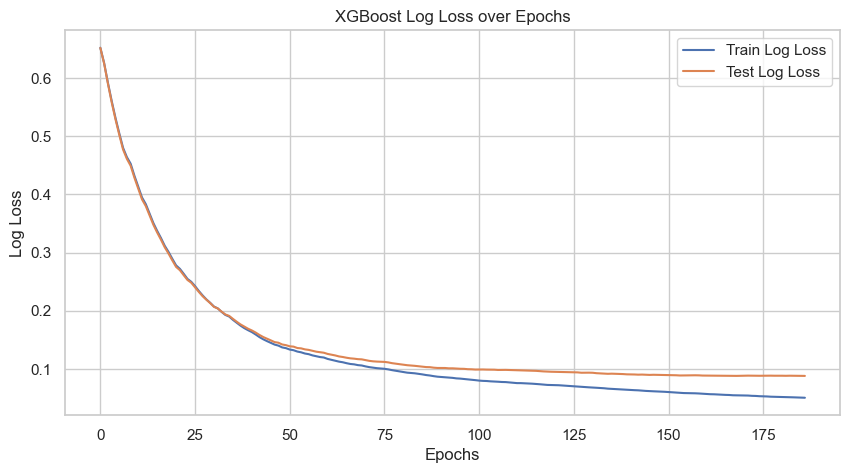

In [ ]:
# 1. Extract results
results = model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

# 2. Plot Log Loss
plt.figure(figsize=(10, 5))
plt.plot(x_axis, results['validation_0']['logloss'], label='Train Log Loss')
plt.plot(x_axis, results['validation_1']['logloss'], label='Test Log Loss')
plt.title('XGBoost Log Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.show()

### Hyper-parameter Tuning (n_estimators)

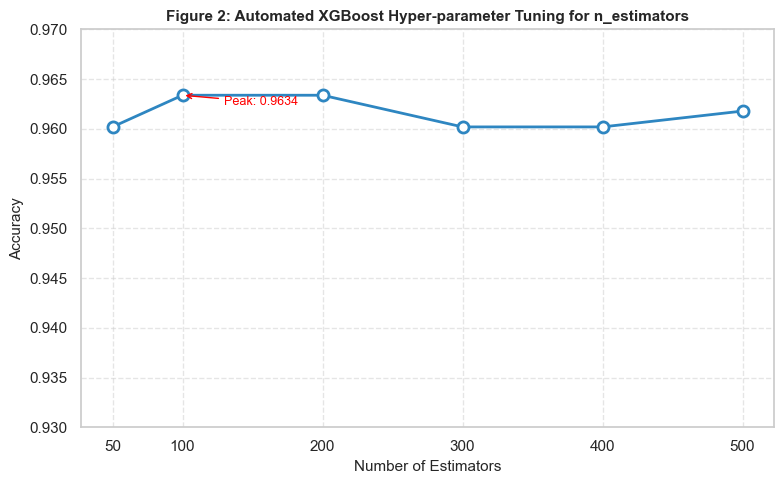

In [ ]:
# Define range of n_estimators to test for model sensitivity and performance
estimator_range = [50, 100, 200, 300, 400, 500]
accuracies = []

# Iteratively train models to identify the optimal number of estimators
for n in estimator_range:
    temp_model = xgb.XGBClassifier(
        n_estimators=n,
        learning_rate=0.05,
        max_depth=4,
        scale_pos_weight=correct_scale_weight,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='auc',
        random_state=42
    )
    temp_model.fit(X_train, y_train, verbose=False)
    # Evaluate accuracy using the established 0.65 threshold
    acc = accuracy_score(y_test, (temp_model.predict_proba(X_test)[:,1] >= 0.65).astype(int))
    accuracies.append(acc)

# Plot accuracy trend against estimator count for visual hyper-parameter optimization
plt.figure(figsize=(8, 5))
plt.plot(estimator_range, accuracies, marker='o', color='#2E86C1',
         linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)
plt.title('Figure 2: Automated XGBoost Hyper-parameter Tuning for n_estimators',
          fontsize=11, fontweight='bold')
plt.xlabel('Number of Estimators', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.xticks(estimator_range)
plt.ylim(0.93, 0.97)
plt.grid(True, linestyle='--', alpha=0.5)

# Annotate the peak performance point on the graph
best_idx = np.argmax(accuracies)
plt.annotate(f'Peak: {accuracies[best_idx]:.4f}',
             xy=(estimator_range[best_idx], accuracies[best_idx]),
             xytext=(estimator_range[best_idx]+30, accuracies[best_idx]-0.001),
             fontsize=9, color='red',
             arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig('figure2_estimators.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Importance Analysis

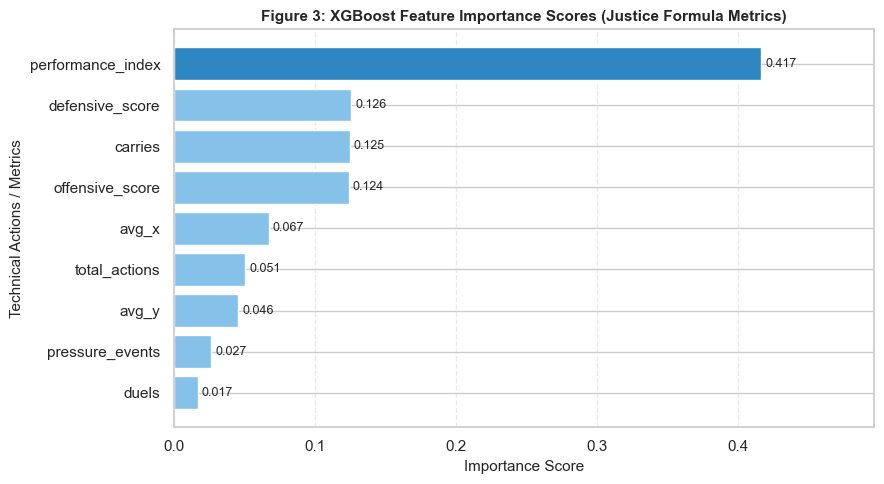

In [ ]:
# Map feature importance scores to the model's features for tactical analysis
feat_imp = pd.Series(model.feature_importances_, index=features).sort_values()

# Highlight the most impactful feature (the Justice Formula metric) in a darker shade
colors = ['#85C1E9' if v < feat_imp.max() else '#2E86C1' for v in feat_imp.values]

# Plot horizontal bar chart to visualize which metrics are driving the Elite classification
plt.figure(figsize=(9, 5))
bars = plt.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white')

# Add numerical labels for clarity on each importance score
for bar, val in zip(bars, feat_imp.values):
    plt.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.title('Figure 3: XGBoost Feature Importance Scores (Justice Formula Metrics)',
          fontsize=11, fontweight='bold')
plt.xlabel('Importance Score', fontsize=11)
plt.ylabel('Technical Actions / Metrics', fontsize=11)
plt.xlim(0, feat_imp.max() + 0.08)
plt.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('figure3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### ROC Curve Analysis

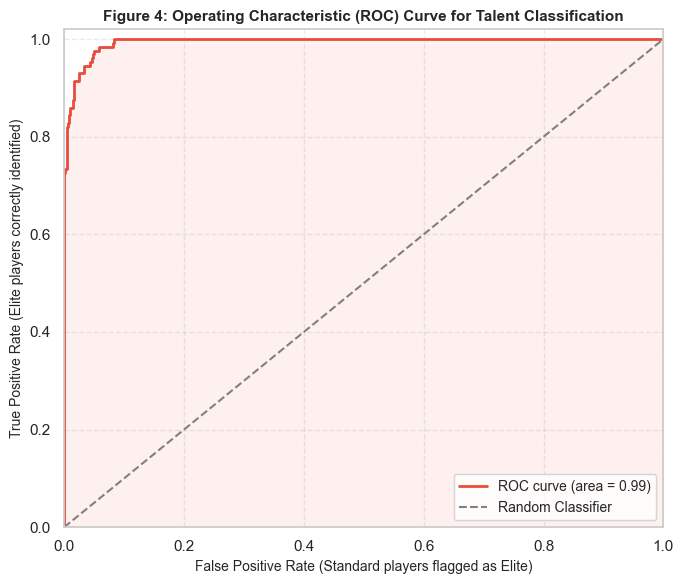

In [ ]:
# Calculate False Positive Rate, True Positive Rate, and Area Under the Curve (AUC)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve to visualize the trade-off between sensitivity and specificity
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#E74C3C', lw=2,
         label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5,
         linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.08, color='#E74C3C')

# Set plot limits, labels, and grid for clear professional presentation
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate (Standard players flagged as Elite)', fontsize=10)
plt.ylabel('True Positive Rate (Elite players correctly identified)', fontsize=10)
plt.title('Figure 4: Operating Characteristic (ROC) Curve for Talent Classification',
          fontsize=11, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('figure4_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### Confusion Matrix for Elite Target Classification

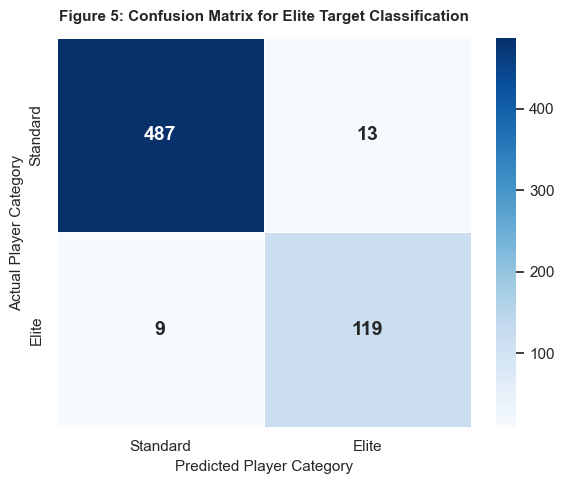

In [ ]:
# Generate a confusion matrix to visualize the model's classification performance
y_pred_final = (y_proba >= 0.65).astype(int)
cm = confusion_matrix(y_test, y_pred_final)

# Create a heatmap to clearly display True Positives, False Positives, True Negatives, and False Negatives
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Standard', 'Elite'],
            yticklabels=['Standard', 'Elite'],
            linewidths=0.5, linecolor='white',
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Figure 5: Confusion Matrix for Elite Target Classification',
          fontsize=11, fontweight='bold', pad=12)
plt.ylabel('Actual Player Category', fontsize=11)
plt.xlabel('Predicted Player Category', fontsize=11)
plt.tight_layout()
plt.savefig('figure5_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Classification Performance Visualization

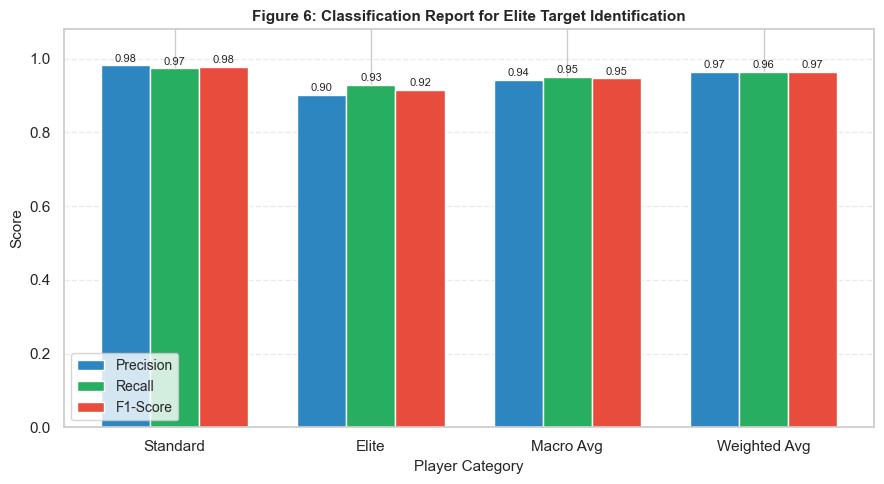

In [ ]:
# Extract metrics from the classification report dictionary for visualization
report = classification_report(y_test, y_pred_final,
                               target_names=['Standard', 'Elite'],
                               output_dict=True)

# Organize metrics for plotting across standard and aggregate categories
categories  = ['Standard', 'Elite', 'Macro Avg', 'Weighted Avg']
precisions  = [report['Standard']['precision'], report['Elite']['precision'],
               report['macro avg']['precision'], report['weighted avg']['precision']]
recalls     = [report['Standard']['recall'],    report['Elite']['recall'],
               report['macro avg']['recall'],    report['weighted avg']['recall']]
f1_scores   = [report['Standard']['f1-score'],  report['Elite']['f1-score'],
               report['macro avg']['f1-score'],  report['weighted avg']['f1-score']]

# Initialize plot parameters
x     = np.arange(len(categories))
width = 0.25

# Generate grouped bar chart to compare Precision, Recall, and F1-Score
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width, precisions, width, label='Precision', color='#2E86C1')
b2 = ax.bar(x,         recalls,   width, label='Recall',    color='#27AE60')
b3 = ax.bar(x + width,  f1_scores, width, label='F1-Score',  color='#E74C3C')

# Annotate bars with numerical values for technical transparency
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=8)

# Configure plot labels, title, and formatting
ax.set_xlabel('Player Category', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Figure 6: Classification Report for Elite Target Identification',
             fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=10)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('figure6_classification_report.png', dpi=150, bbox_inches='tight')
plt.show()

## PAHSE 7: Save model

In [ ]:
# Save the trained XGBoost model along with its optimized decision threshold and feature list
import joblib

joblib.dump(
    {'model': model, 'threshold': best_threshold, 'features': features},
    'xgboost_scouting_model.pkl'
)
print("Model saved correctly as dict!")

Model saved correctly as dict!


## Final Reporting Tables (Tables 4-9)

In [42]:
# TABLE 4: Statistical Analysis
print("\n" + "="*60 + "\nTABLE 4 — Statistical Analysis of the Dataset\n" + "="*60)
print(training_df[['total_actions', 'avg_x', 'performance_index']].describe().loc[['mean','50%','std','max','min']].rename(index={'50%':'median'}))

# TABLE 5: Correlation Analysis
print("\n" + "="*60 + "\nTABLE 5 — Correlation Analysis\n" + "="*60)
pairs = {
    'Total actions vs Perf. Index': training_df['total_actions'].corr(training_df['performance_index']),
    'Avg X vs Perf. Index': training_df['avg_x'].corr(training_df['performance_index']),
    'Interceptions vs Perf. Index': training_df['interceptions'].corr(training_df['performance_index']),
    'Defensive Score vs Perf. Index': training_df['defensive_score'].corr(training_df['performance_index']),
    'Offensive Score vs Perf. Index': training_df['offensive_score'].corr(training_df['performance_index']),
}
for k, v in pairs.items(): print(f"  {k}: {v:.2f}")

# TABLE 6: Optimum Parameters
print("\n" + "="*60 + "\nTABLE 6 — Optimum Parameters\n" + "="*60)
params = model.get_params()
for k in ['n_estimators','learning_rate','max_depth','subsample','colsample_bytree']: print(f"  {k}: {params[k]}")
print(f"  scale_pos_weight: {correct_scale_weight}\n  Decision Threshold: {best_threshold}")

# TABLE 7: Comparative Performance
print("\n" + "="*60 + "\nTABLE 7 — Comparative Performance (LR vs XGBoost)\n" + "="*60)
print(f"  LR  Accuracy : {accuracy_score(y_test, lr_pred)*100:.2f}% | XGB Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"  LR  AUC      : {roc_auc_score(y_test, lr_proba):.4f} | XGB AUC      : {roc_auc_score(y_test, y_proba):.4f}")
print(f"  LR  Precision: {precision_score(y_test, lr_pred):.2f} | XGB Precision: {precision_score(y_test, y_pred):.2f}")
print(f"  LR  Recall   : {recall_score(y_test, lr_pred):.2f} | XGB Recall   : {recall_score(y_test, y_pred):.2f}")

# TABLE 8: Classification Report (XGBoost)
print("\n" + "="*60 + "\nTABLE 8 — Classification Report (XGBoost)\n" + "="*60)
print(classification_report(y_test, y_pred, target_names=['Standard','Elite']))

# TABLE 9: Feature Subsets
print("\n" + "="*60 + "\nTABLE 9 — Feature Subsets Accuracy\n" + "="*60)
subsets = {
    'All 9 features': features,
    'Top 6': ['total_actions','avg_x','offensive_score','defensive_score','performance_index','carries'],
    'Top 4': ['performance_index','defensive_score','offensive_score','carries'],
    'Top 2': ['performance_index','defensive_score'],
}
for name, feats in subsets.items():
    tmp = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, 
                            scale_pos_weight=correct_scale_weight, subsample=0.8, 
                            colsample_bytree=0.8, random_state=42, eval_metric='auc', verbosity=0)
    tmp.fit(X_train[feats], y_train)
    p = tmp.predict_proba(X_test[feats])[:, 1]
    print(f"  {name}: {accuracy_score(y_test, (p >= best_threshold).astype(int))*100:.2f}%")


TABLE 4 — Statistical Analysis of the Dataset
        total_actions       avg_x  performance_index
mean       134.421656   62.126747           4.963980
median      44.000000   62.748125           2.822141
std        530.735975   16.241732           7.708329
max      10995.000000  120.000000         100.000000
min          1.000000    1.900000           0.000000

TABLE 5 — Correlation Analysis
  Total actions vs Perf. Index: -0.04
  Avg X vs Perf. Index: -0.33
  Interceptions vs Perf. Index: 0.09
  Defensive Score vs Perf. Index: 0.08
  Offensive Score vs Perf. Index: 0.00

TABLE 6 — Optimum Parameters
  n_estimators: 200
  learning_rate: 0.05
  max_depth: 4
  subsample: 0.8
  colsample_bytree: 0.8
  scale_pos_weight: 3.91
  Decision Threshold: 0.6499999999999999

TABLE 7 — Comparative Performance (LR vs XGBoost)
  LR  Accuracy : 95.38% | XGB Accuracy : 96.50%
  LR  AUC      : 0.9838 | XGB AUC      : 0.9943
  LR  Precision: 0.90 | XGB Precision: 0.90
  LR  Recall   : 0.87 | XGB Recall 